In [1]:
import sys
sys.path.append('../src')

import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler

from third_meeting.noisy_8_qubit import get_circuits_and_outputs
from fifth_meeting.visualizer import TransitionPointsVisualizer
from fifth_meeting.create_dataset import get_supermarq_features
from fifth_meeting.create_dataset import HammingDecayPredictor

print("All imports successful!")

All imports successful!


In [2]:
loaded = np.load(f'../data/third_meeting/all_circuits_data.npz', allow_pickle=True)
names_dataset = loaded['names']
shots_dataset = loaded['shots_dataset']
noise_dataset = loaded['noise_dataset']
hamming_dataset = loaded['hamming_data']
hellinger_dataset = loaded['hellinger_data']

In [3]:
################# DATA-PRE-PROCESSING #################

#--- Only keep the variational circuits (from 1 to 18)
names_dataset = names_dataset[1:19]
shots_dataset = shots_dataset[1:19]
noise_dataset = noise_dataset[1:19]
hamming_dataset = hamming_dataset[1:19]
hellinger_dataset = hellinger_dataset[1:19]


#--- Smooth Hellinger and Hamming datasets with savgol filter twice

from scipy.signal import savgol_filter

smoothed_hellinger = np.array([
            [savgol_filter(savgol_filter(hellinger_dataset[i][j], 11, 2), 11, 2)
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

smoothed_hamming = np.array([
            [[savgol_filter(savgol_filter(hamming_dataset[i][j][k], 11, 2), 11, 2)
              for k in range(len(noise_dataset[i]))]
             for j in range(10)]
            for i in range(len(names_dataset))
        ])

#--- Cut first n shots to avoid the overbearing initial fluctuations (not used currently)
n_shots_to_cut = 0
cut_shots = shots_dataset[:, n_shots_to_cut:]
cut_hellinger = smoothed_hellinger[:, :, n_shots_to_cut:]
cut_hamming = smoothed_hamming[:, :, :, n_shots_to_cut:]

#--- Cut first noise level (noise is 0.0), because Hamming is 0 there
cut_noise = noise_dataset[:, 1:]
cut_hellinger = cut_hellinger[:, 1:, :]
cut_hamming = cut_hamming[:, :, 1:, :]

#--- Get only first 50 shots (0 - 1000 shot simulations), because they have smallest delta
n_shots_to_get = 50
cut_shots = cut_shots[:, :n_shots_to_get]
cut_hellinger = cut_hellinger[:, :, :n_shots_to_get]
cut_hamming = cut_hamming[:, :, :, :n_shots_to_get]


In [4]:
################# VISUALIZATION #################
visualizer1 = TransitionPointsVisualizer(names_dataset, cut_shots, cut_noise, cut_hamming, cut_hellinger, 8)
visualizer1.pre_compute_saturation_points()
visualizer1.saturation_points_correlation_dashboard()

interactive(children=(Dropdown(description='Circuit:', options=((np.str_('varQC_linear_2r'), 0), (np.str_('var…

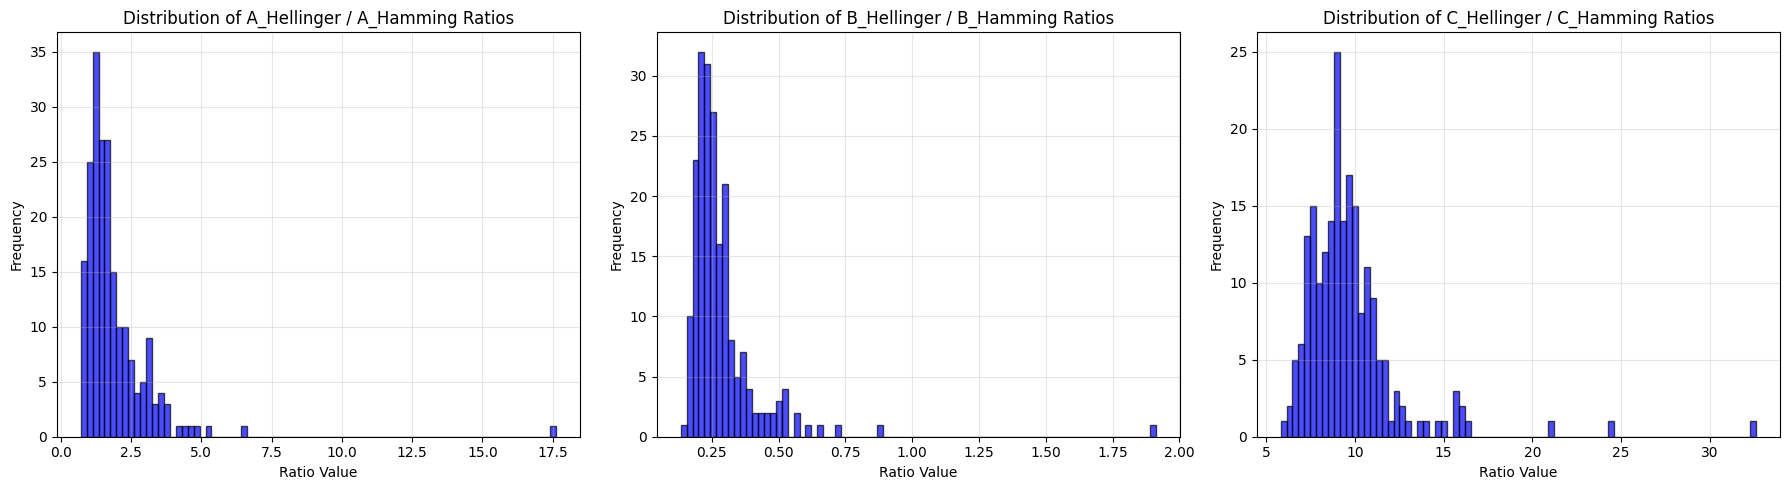

In [5]:
visualizer1.plot_ABC_correlations(range(0, 18))

Outlier 1: varQC_linear_2r


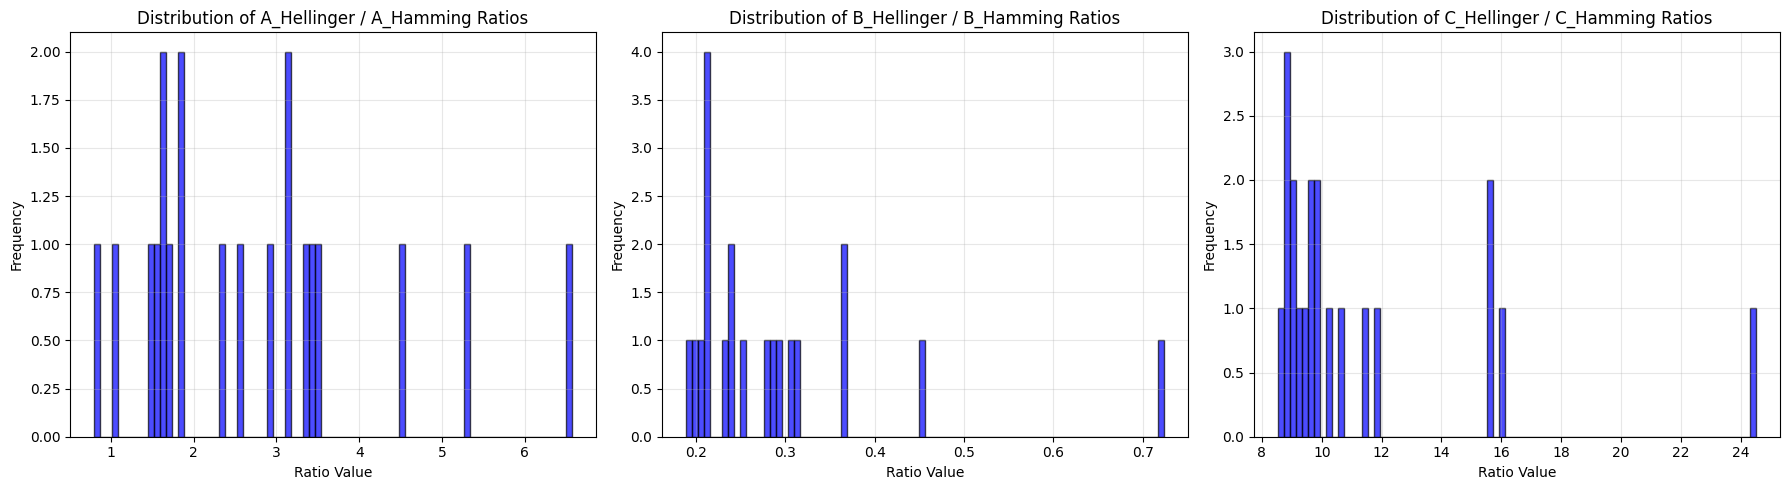

Outlier 2: RealAmp_linear_2r


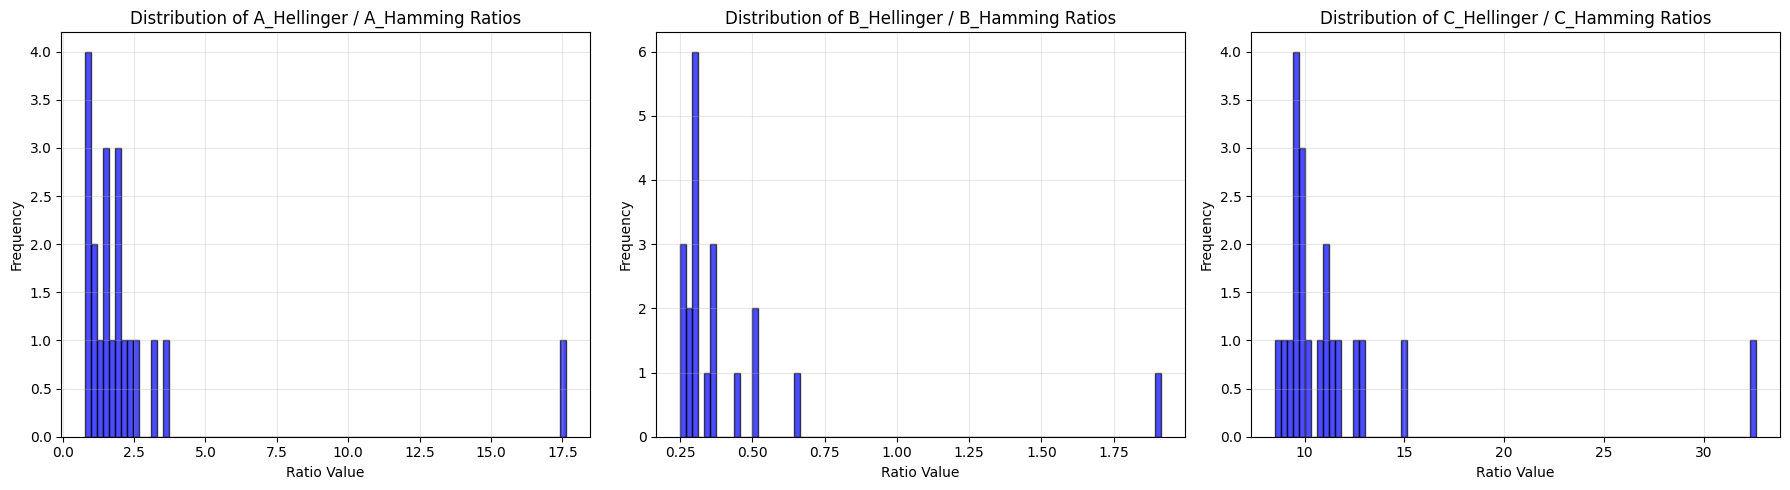

In [6]:
#--- Which are the outliers in the ABC correlation plots?

print("Outlier 1:", names_dataset[0])
visualizer1.plot_ABC_correlations([0])
print("Outlier 2:", names_dataset[12])
visualizer1.plot_ABC_correlations([12])

The outliers seem to be 2 reps linear entanglement circuits, let's try to discover wich noise level causes the outlier

Outlier 1: varQC_linear_2r


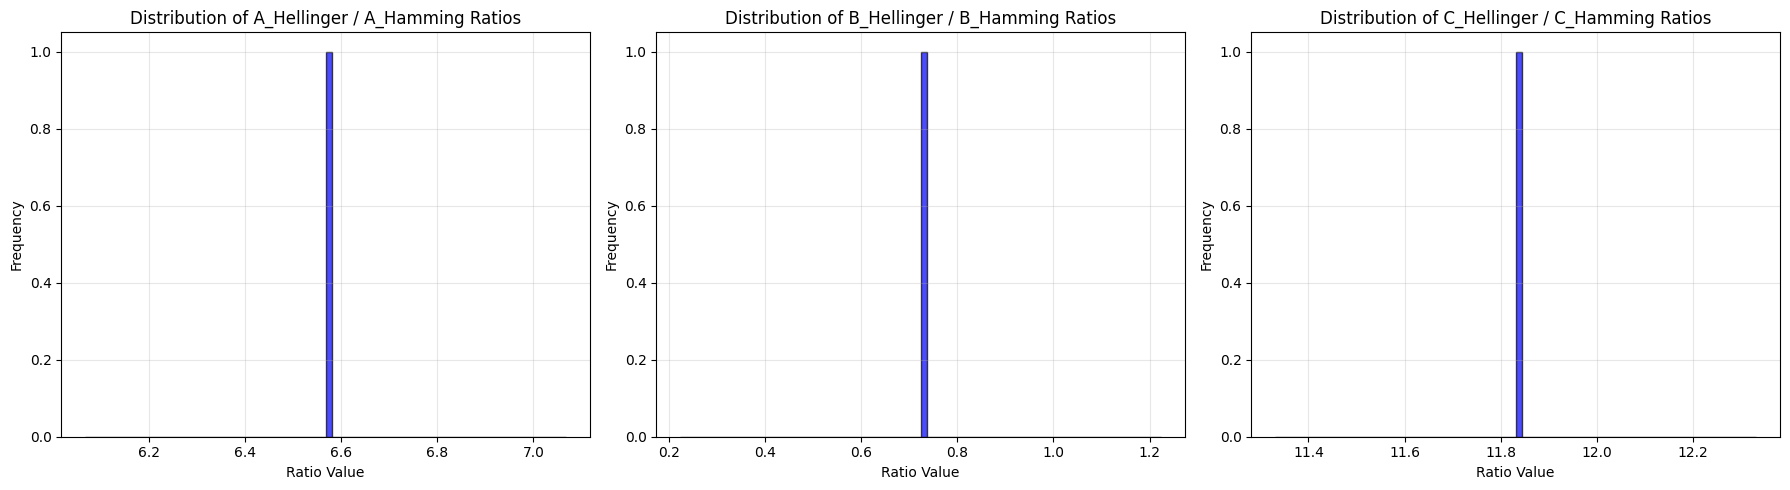

Outlier 3: RealAmp_linear_2r


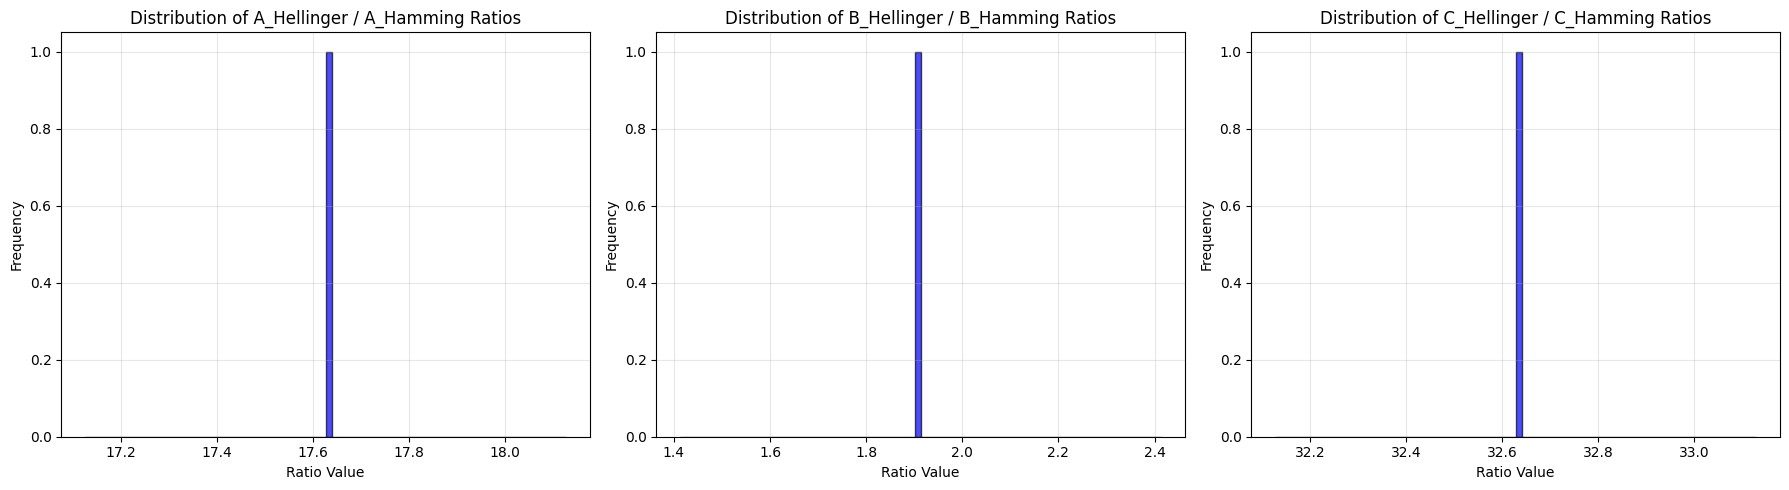

In [7]:
print("Outlier 1:", names_dataset[0])
visualizer1.plot_ABC_correlations([0],5)
print("Outlier 3:", names_dataset[12])
visualizer1.plot_ABC_correlations([12],0)

If we take a look at the Hamming curve of both of these specific circuits with the corresponding specific errors,  
we can see that it is abnormally flat in the third_meeting.ipynb notebook, making it very hard to predict the Hellinger.
However these are just 2 samples of 207 total which is less than 1%.  
Also the Hellinger that we are looking for is almost the same as the one from Neighbouring noise level, which means we can
still predict it accurately using an "assumed" or AI-generated(meaning one that fits with most of the data) Hamming std.  

# We can rule out these outliers as non-significant

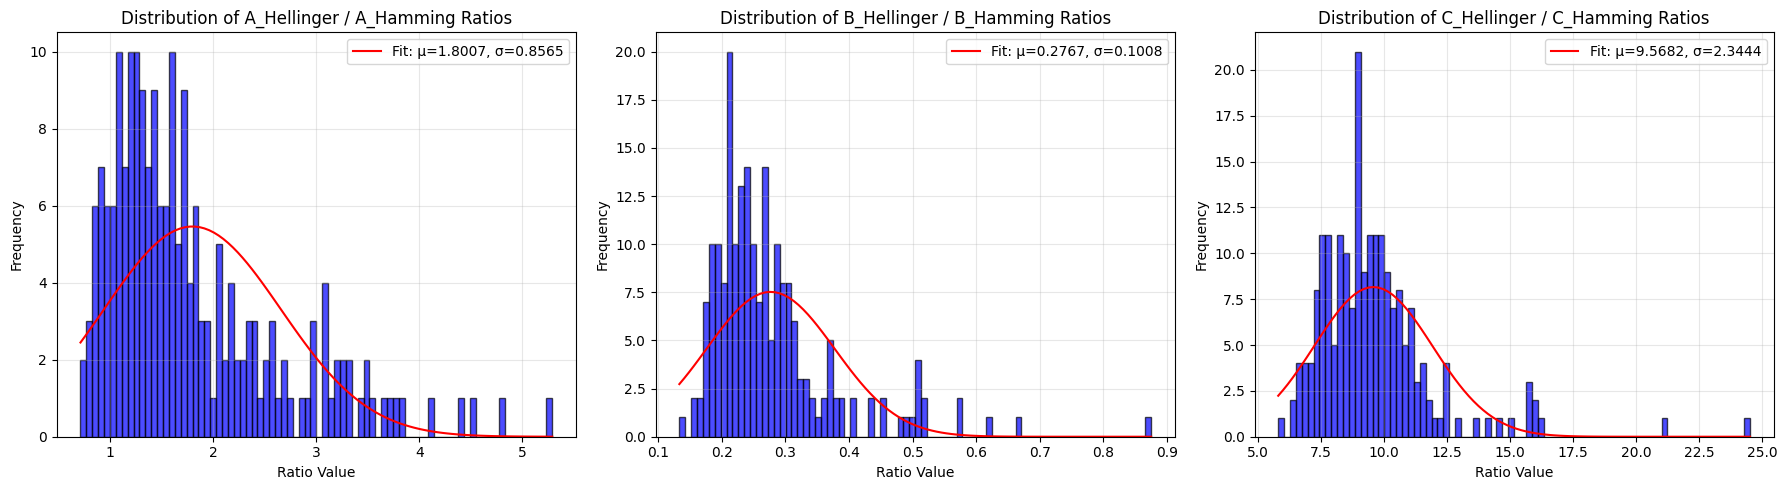

In [8]:
### Visualizer for the modified dataset without outliers

visualizer2 = TransitionPointsVisualizer(names_dataset, cut_shots, cut_noise, cut_hamming, cut_hellinger, 8)
visualizer2.plot_ABC_correlations(range(0, 18), display_bell_curve_fit=True, skip_circuit_noise_combinations=[(0, 5), (12, 0)])

# Experiment trying to predict Hellinger(and its saturation point) from Hamming by using the mean from A, B, C ratios

In [ ]:
visualizer2.transition_points_dashboard()

interactive(children=(Dropdown(description='Circuit:', options=((np.str_('varQC_linear_2r'), 0), (np.str_('var…

# Dataset creation

In [13]:
### Get Supermarq features for the circuits

circuits_and_outputs = get_circuits_and_outputs()
circuits = circuits_and_outputs['mirrored_circuits']

supermarq_features = get_supermarq_features(circuits)

In [14]:
### Prepare data for training visualizer and get noise levels

loaded = np.load(f'../data/third_meeting/all_circuits_data.npz', allow_pickle=True)
names_dataset = loaded['names']
shots_dataset = loaded['shots_dataset']
noise_dataset = loaded['noise_dataset']
hamming_dataset = loaded['hamming_data']
hellinger_dataset = loaded['hellinger_data']

#--- Remove the random circuits 19:24
names_dataset = names_dataset[0:19]
shots_dataset = shots_dataset[0:19]
noise_dataset = noise_dataset[0:19]
hamming_dataset = hamming_dataset[0:19]
hellinger_dataset = hellinger_dataset[0:19]

#--- Smooth Hellinger and Hamming datasets with savgol filter twice

from scipy.signal import savgol_filter

smoothed_hellinger = np.array([
            [savgol_filter(savgol_filter(hellinger_dataset[i][j], 11, 2), 11, 2)
             for j in range(len(noise_dataset[i]))]
            for i in range(len(names_dataset))
        ])

smoothed_hamming = np.array([
            [[savgol_filter(savgol_filter(hamming_dataset[i][j][k], 11, 2), 11, 2)
              for k in range(len(noise_dataset[i]))]
             for j in range(10)]
            for i in range(len(names_dataset))
        ])

#--- Cut first n shots to avoid the overbearing initial fluctuations
n_shots_to_cut = 0
cut_shots = shots_dataset[:, n_shots_to_cut:]
cut_hellinger = smoothed_hellinger[:, :, n_shots_to_cut:]
cut_hamming = smoothed_hamming[:, :, :, n_shots_to_cut:]

#--- Cut first noise level (noise is 0.0), because Hamming is 0 there
cut_noise = noise_dataset[:, 1:]
cut_hellinger = cut_hellinger[:, 1:, :]
cut_hamming = cut_hamming[:, :, 1:, :]

#--- Get only first 50 shots (0 - 1000 shot simulations), because they have smallest delta
n_shots_to_get = 50
cut_shots = cut_shots[:, :n_shots_to_get]
cut_hellinger = cut_hellinger[:, :, :n_shots_to_get]
cut_hamming = cut_hamming[:, :, :, :n_shots_to_get]

training_visualizer = TransitionPointsVisualizer(names_dataset, cut_shots, cut_noise, cut_hamming, cut_hellinger, 8)
training_visualizer.pre_compute_saturation_points()

In [ ]:
### Prepare Dataset for training

# for each supermarq feature append all possible noise levels (20) to get a dataset of shape (24*20, 4+1) where the last column is the noise level
X_train = []
for i in range(len(names_dataset)):
    for j in range(len(cut_noise[i])):
        X_train.append(np.concatenate((supermarq_features[i], [cut_noise[i][j]])))
X_raw = np.array(X_train)

# labels for every circuit per noise level are the corresponding A, B, C parameters of the Hamming decay of shape (24, 20, 3) -> reshape to (24*20, 3)

poly_hamming_std_ABC = training_visualizer.poly_hamming_std_ABC

y_train = []
for i in range(len(names_dataset)):
    for j in range(len(cut_noise[i])):
        y_train.append(poly_hamming_std_ABC[i, j])

Y_raw = np.array(y_train)

# print("X_raw shape:", X_raw.shape)  # Should be (24*20, 5)
# print("Y_raw shape:", Y_raw.shape)  # Should be (24*20, 3)

# Save the training data for later use
np.savez('../data/fifth_meeting/training_data.npz', X=X_raw, Y=Y_raw)



In [2]:


# load the training data
X_raw, Y_raw = np.load('../data/fifth_meeting/training_data.npz')['X'], np.load('../data/fifth_meeting/training_data.npz')['Y']

scaler_Y = StandardScaler()
Y_scaled = scaler_Y.fit_transform(Y_raw)

# Convert to PyTorch Tensors
X_tensor = torch.tensor(X_raw, dtype=torch.float32)
Y_tensor = torch.tensor(Y_scaled, dtype=torch.float32)


# Create DataLoader
dataset = TensorDataset(X_tensor, Y_tensor)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [4]:
### Initialize the HammingDecayPredictor model and train it
model = HammingDecayPredictor(input_dim=5, output_dim=3)

# MSE Loss is standard for regression. 
# If you have extreme outliers from bad curve fits, consider nn.HuberLoss() instead.
#criterion = nn.MSELoss()
criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

#--- Training loop
epochs = 1000
model.train()

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        
        # Forward pass
        predictions = model(batch_X)
        
        # Compute loss
        loss = criterion(predictions, batch_Y)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * batch_X.size(0)
        
    total_epoch_loss = epoch_loss / len(train_loader.dataset)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_epoch_loss:.4f}")

Epoch [10/1000], Loss: 0.4038
Epoch [20/1000], Loss: 0.3931
Epoch [30/1000], Loss: 0.3902
Epoch [40/1000], Loss: 0.3891
Epoch [50/1000], Loss: 0.3867
Epoch [60/1000], Loss: 0.3854
Epoch [70/1000], Loss: 0.3832
Epoch [80/1000], Loss: 0.3818
Epoch [90/1000], Loss: 0.3803
Epoch [100/1000], Loss: 0.3782
Epoch [110/1000], Loss: 0.3767
Epoch [120/1000], Loss: 0.3751
Epoch [130/1000], Loss: 0.3732
Epoch [140/1000], Loss: 0.3719
Epoch [150/1000], Loss: 0.3713
Epoch [160/1000], Loss: 0.3700
Epoch [170/1000], Loss: 0.3675
Epoch [180/1000], Loss: 0.3663
Epoch [190/1000], Loss: 0.3646
Epoch [200/1000], Loss: 0.3627
Epoch [210/1000], Loss: 0.3617
Epoch [220/1000], Loss: 0.3601
Epoch [230/1000], Loss: 0.3596
Epoch [240/1000], Loss: 0.3567
Epoch [250/1000], Loss: 0.3548
Epoch [260/1000], Loss: 0.3521
Epoch [270/1000], Loss: 0.3509
Epoch [280/1000], Loss: 0.3477
Epoch [290/1000], Loss: 0.3482
Epoch [300/1000], Loss: 0.3435
Epoch [310/1000], Loss: 0.3421
Epoch [320/1000], Loss: 0.3404
Epoch [330/1000],

In [ ]:
#--- Predict Hamming A, B, C parameters for the training data
model.eval()
with torch.no_grad():
    Y_pred_scaled = model(X_tensor)
    Y_pred = scaler_Y.inverse_transform(Y_pred_scaled.numpy())

print(Y_pred.shape)

Y_reshaped = Y_pred.reshape(19, 20, 3)

training_visualizer.update_hamming_std_fit(Y_reshaped)
training_visualizer.transition_points_dashboard()



(380, 3)
(19, 20, 3)
